In [2]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize_scalar, brentq
import mpmath as mp
from scipy import special
import matplotlib.pyplot as plt
import time
mp.mp.dps = 50

In [3]:
def iszero(a, eps=1e-6):
    if np.abs(a) < eps:
        return True
    return False

def inv_cdf(a, v):
    if iszero(a):
        return v
    return 1/a*(a/2-1+np.sqrt(2*a*v + (a/2-1)**2))

def inv_cdf_deriv(a, v):
    if iszero(a):
        return -1/8*(2*v-1)**2 + 1/8
    temp = np.sqrt(2*a*v + (a/2-1)**2)
    return 1/a**2 * (1. - temp) + 1/2/a / temp * (2*v + a/2 - 1)

def inv_cdf_numerical_deriv(a, v, eps=1e-3):
    # if iszero(a):
    #     return np.zeros_like(v)
    return (inv_cdf(a+eps, v) - inv_cdf(a-eps, v)) / 2 / eps

def get_m1_k_(a, k, n):
    if iszero(a):
        return k/(n+1)
    b = (0.5*a-1)**2
    return float(0.5 - 1/a + np.sqrt(b) / a * special.hyp2f1(-0.5, k, n+1, -2*a/b))

def get_m1_k(a, k, n):
    if iszero(a):
        return k/(n+1)
    b = (0.5*a-1)**2
    return float(0.5 - 1/a + np.sqrt(b) / a * mp.hyp2f1(-0.5, k, n+1, -2*a/b))

def get_m2(a):
    return (a+4)/12

def expected_wasserstein_loss_affine(a1, a2, n, m1_a1=None, m1_a2=None):
    if m1_a1 is None:
        m1_a1 = np.array([get_m1_k(a1, k+1, n) for k in range(n)])
    if m1_a2 is None:
        m1_a2 = np.array([get_m1_k(a2, k+1, n) for k in range(n)])
    dist = -2*np.mean(m1_a1*m1_a2) + get_m2(a1) + get_m2(a2)
    return dist

def expected_self_wasserstein_loss_affine(a, n, m1_a=None):
    if m1_a is None:
        m1_a = np.array([get_m1_k(a, k+1, n) for k in range(n)])
    return expected_wasserstein_loss_affine(a, a, n, m1_a1=m1_a, m1_a2=m1_a)

def expected_self_wasserstein_loss_affine_grad(a, n, eps=1e-3):
    distp = expected_self_wasserstein_loss_affine(a + eps, n)
    distm = expected_self_wasserstein_loss_affine(a - eps, n)
    return (distp - distm)/2/eps

In [4]:
def quantile_moment(a, k, n, eps=1e-6):
    if iszero(a, eps):
        return (2*k-1)/2/n**2
    b = (0.5*a-1)**2
    return (1/2-1/a)/n + 1/3/a**2*((2*a*k/n + b)**(3/2) - (2*a*(k-1)/n + b)**(3/2))

def expected_invcdf_block(a, k, n, eps=1e-6):
    if iszero(a, eps):
        return (2*k-1)/2/n**2
    ad = 2*a
    cd = a/2-1
    bd = cd**2
    return cd/a/n + 2/3/a/ad*((ad*k/n + bd)**(3/2) - (ad*(k-1)/n + bd)**(3/2))

# --------------------------------------------------------------------- #
#  Analytic derivatives                                                 #
# --------------------------------------------------------------------- #
def _g(a: float, k: np.ndarray, N: int) -> np.ndarray:
    """g_k(a) for an array of k."""
    return 2.0 * a * k / N + (0.5 * a - 1.0) ** 2

def _delta_phi(a: float, k: np.ndarray, N: int) -> np.ndarray:
    """Δφ_k(a) = φ_k − φ_{k−1} as vector over k."""
    gk   = _g(a, k,   N)
    gkm1 = _g(a, k-1, N)
    return gk**1.5 - gkm1**1.5
    
def _delta_phi_prime(a: float, k: np.ndarray, N: int) -> np.ndarray:
    """d/da Δφ_k(a)."""
    # derivative of g_k
    gk   = _g(a, k,   N)
    gkm1 = _g(a, k-1, N)
    gk_p   = 2.0 * k / N + 0.5 * a - 1.0
    gkm1_p = 2.0 * (k-1) / N + 0.5 * a - 1.0
    return 1.5 * (gk_p * np.sqrt(gk) - gkm1_p * np.sqrt(gkm1))

def quantile_moment_prime(a, k, N,
               dφ = None,
               dφ_p = None):
    if iszero(a, eps=1e-3):
        return (6*N*k - 3*N - 6*k*k + 6*k - 2) / 12 / N**3
    if dφ is None:
        dφ = _delta_phi(a, k, N)
    if dφ_p is None:
        dφ_p = _delta_phi_prime(a, k, N)

    return (1.0 / (N * a * a)
            - 2.0 * dφ / (3.0 * a**3)
            + dφ_p / (3.0 * a * a))

def expected_W_emp_emp_affine(x, a, m1s=None, r=1):
    N   = x.size
    if m1s is None:
        m1s = np.array([get_m1_k(a, i+1, r*N) for i in range(r*N)])
    return np.mean(-2.0 * np.repeat(x, r) * m1s) + np.sum(x*x)/N + get_m2(a)

def expected_W_emp_emp_affine_(x, a, m1s=None, r=1):
    N   = x.size
    if m1s is None:
        m1s = np.array([get_m1_k_(a, i+1, r*N) for i in range(r*N)])
    return np.mean(-2.0 * np.repeat(x, r) * m1s) + np.sum(x*x)/N + get_m2(a)

def expected_W_emp_emp_affine_grad(x, a, r=1, eps=1e-3):
    EWp = expected_W_emp_emp_affine(x, a+eps, r=r)
    EWm = expected_W_emp_emp_affine(x, a-eps, r=r)
    return (EWp - EWm) / 2 / eps

def W_emp_conti_affine(x, a, q1s=None):
    N   = x.size
    if q1s is None:
        q1s = np.array([quantile_moment(a, i+1, N) for i in range(N)])
    return np.sum(-2.0 * x * q1s) + get_m2(a) + np.sum(x*x)/N

def expected_W_emp_conti_affine(a1, a2, N, m1s=None, q1s=None):
    if m1s is None:
        m1s = np.array([get_m1_k(a1, i+1, N) for i in range(N)])
    if q1s is None:
        q1s = np.array([quantile_moment(a2, i+1, N) for i in range(N)])
    return np.sum(-2.0 * m1s * q1s) + get_m2(a2) + get_m2(a1)

def expected_W_emp_conti_affine_grad(a1, a2, N, m1s=None, eps=1e-3):
    if m1s is None:
        m1s = np.array([get_m1_k(a1, i+1, N) for i in range(N)])
    EWp = expected_W_emp_conti_affine(a1, a2+eps, N, m1s=m1s)
    EWm = expected_W_emp_conti_affine(a1, a2-eps, N, m1s=m1s)
    return (EWp - EWm) / 2 / eps

In [5]:
def numerical_sol_expected_loss(a1: float,
                         n:  int,
                        m1_a1 = None,
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        return float(expected_wasserstein_loss_affine(a1, a2, n, m1_a1=m1_a1))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2, 2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [6]:
def numerical_sol_expected_loss_debias(a1: float,
                         n:  int,
                        m1_a1 = None,
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        m1_a2 = np.array([get_m1_k(a2, k+1, n) for k in range(n)])
        return float(expected_wasserstein_loss_affine(a1, a2, n, m1_a1=m1_a1, m1_a2=m1_a2) - 0.5*expected_wasserstein_loss_affine(a2, a2, n, m1_a1=m1_a2, m1_a2=m1_a2))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2, 2),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [7]:
def minimise_wasserstein_emp_conti(x, 
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   W_emp_conti_affine(x, a).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a):
        return float(W_emp_conti_affine(x, a))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2.0 + eps, 2.0 - eps),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

def minimise_expected_W_emp_conti(a1, n, m1_a1=None, alpha=0,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_W_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a):
        return float(expected_W_emp_conti_affine(a1, a, n, m1s=m1_a1) - alpha*expected_self_wasserstein_loss_affine(a,n))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2.0 + eps, 2.0 - eps),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

def minimise_expected_W_emp_emp(x, r=1, alpha=0,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_W_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a):
        n = len(x)
        return float(expected_W_emp_emp_affine(x, a, r=r) - alpha*expected_self_wasserstein_loss_affine(a,n*r))

    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2.0 + eps, 2.0 - eps),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [8]:
def minimise_alpha_var(a1, N_set, m1_a1s=None,
                                   eps: float = 1e-6,
                                     *,
                                     xtol: float = 1e-10,
                                     maxiter: int = 500):
    """
    Find a* that minimises   expected_W_emp_emp_affine(x, a, m1s=None, r=1).

    Parameters
    ----------
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    # convenience wrapper around the user‑supplied objective
    def _obj(a2):
        temp_alpha_set = np.empty(len(N_set))
        for j, N in enumerate(N_set):
            S_grad = expected_self_wasserstein_loss_affine_grad(a2, N)
            if m1_a1s is None:
                m1_a1 = None
            else:
                m1_a1 = m1_a1s[str(N)]
            J_SDa_grad = expected_W_emp_conti_affine_grad(a1, a2, N, m1s=m1_a1)
            temp_alpha = J_SDa_grad / S_grad
            temp_alpha_set[j] = temp_alpha
        return np.var(temp_alpha_set)
        
    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=(-2.0 + eps, 2.0 - eps),
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)



In [9]:
def emp_wass_1dim(x1, x2):
    x1 = np.sort(x1)
    x2 = np.sort(x2)
    N1 = len(x1)
    N2 = len(x2)
    r = N2//N1
    temp = 0
    for i in range(N1):
        temp += (x1[i] - x2[i*r:(i+1)*r])**2
    return (temp).sum()/N2



In [24]:
def get_alpha_dagger(a1, N_set):
    m1_a1s = dict()
    for N in N_set:
        m1_a1s[str(N)] = np.array([get_m1_k(a1, i+1, N) for i in range(N)])

    a2_set = np.concatenate([np.linspace(-1.99, 1.99, 200)])
    temp_alpha_set = np.empty((len(a2_set), len(N_set)))
    S_grad_set = np.empty((len(a2_set), len(N_set)))
    J_SDa_set = np.empty((len(a2_set), len(N_set)))
    for i, a2 in enumerate(a2_set):
        for j, N in enumerate(N_set):
            S_grad = expected_self_wasserstein_loss_affine_grad(a2, N)
            J_SDa_grad = expected_W_emp_conti_affine_grad(a1, a2, N, m1s = m1_a1s[str(N)])
            temp_alpha = J_SDa_grad / S_grad
            temp_alpha_set[i,j] = temp_alpha
            S_grad_set[i,j] = S_grad
            J_SDa_set[i,j] = J_SDa_grad
    a2_heu, fval = minimise_alpha_var(a1, N_set, m1_a1s=m1_a1s)
    print(f"a2_heu: {a2_heu}")
    
    plt.figure(figsize=(4,3))
    plt.plot(a2_set, np.std(temp_alpha_set, axis=-1))
    plt.ylim(0,10)
    plt.grid()
    plt.xlabel(r'$a$', fontsize=12)
    plt.ylabel(r'$stdev[\alpha_{N}(a)]$', fontsize=12)
    plt.axvline([a1], color="k", linestyle="dashed")
    plt.show()

    temp_alpha_heu_set = np.empty(len(N_set))
    for j, N in enumerate(N_set):
        S_grad_heu = expected_self_wasserstein_loss_affine_grad(a2_heu, N)
        J_SDa_grad_heu = expected_W_emp_conti_affine_grad(a1, a2_heu, N, m1s = m1_a1s[str(N)])
        temp_alpha_heu_set[j] = J_SDa_grad_heu / S_grad_heu
    alpha_heu = np.mean(temp_alpha_heu_set)
    print(f"alpha_heu: {alpha_heu}")
    
    idx=0
    a_set = np.empty(len(N_set))
    a_bias_corrected_a0_5 = np.empty(len(N_set))
    a_bias_corrected_a = np.empty(len(N_set))
    temp_alphas = np.empty(len(N_set))
    alpha = alpha_heu
    print(alpha)
    
    for i, N in enumerate(N_set):
        # print(N)
        a_set[i], _ = minimise_expected_W_emp_conti(a1, N, m1_a1=m1_a1s[str(N)], alpha=0)
        a_bias_corrected_a0_5[i], _ = minimise_expected_W_emp_conti(a1, N, m1_a1=m1_a1s[str(N)], alpha=0.5)
        a_bias_corrected_a[i], _ =minimise_expected_W_emp_conti(a1, N, m1_a1=m1_a1s[str(N)], alpha=alpha)
        
    plt.figure(figsize=(4,3))
    plt.axhline([a1], color='k', ls='--', label=r'$a^*$', zorder=20)
    plt.plot(N_set, a_set, label=r'$\alpha$=0.0', marker='o', zorder=10)
    plt.plot(N_set, a_bias_corrected_a0_5, label=r'$\alpha$=0.5', marker='o', zorder=3)
    plt.plot(N_set, a_bias_corrected_a, label=rf'$\alpha^\dagger$={alpha:.3f}', marker='o', zorder=5)
    plt.grid()
    plt.xlabel(f'N', fontsize=12)
    plt.ylabel(r'$\hat{a}_N$', fontsize=12)
    # plt.ylim(-1, -0.95)
    plt.legend()
    plt.show()

    res = dict()
    res['a2_heu'] = a2_heu
    res['alpha_heu'] = alpha_heu
    res['alpha_set'] = temp_alpha_set
    res['a_set'] = a_set
    res['a_bias_corrected_a0_5'] = a_bias_corrected_a0_5
    res['a_bias_corrected_a'] = a_bias_corrected_a
    return res

In [17]:
N_set = [5,10,15,20,35,50,75,100]

In [19]:
res_set = dict()

a2_heu: 1.0008352417509996


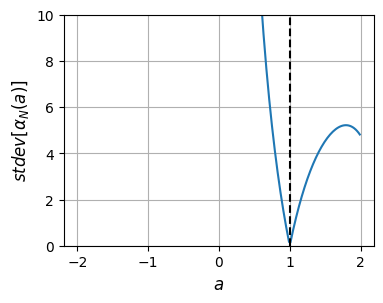

alpha_heu: 0.21082133803584568
0.21082133803584568
5
-0.5965117024326873
10
-1.3935444562792587
15
-2.1637139489981645
20
-2.9260363974510444
35
-5.1981948121954105
50
-7.4636823653212545
75
-11.236827284984795
100
-15.01038245613693


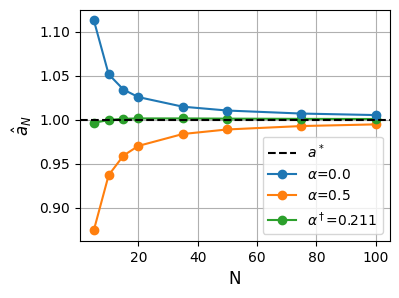

In [20]:
a1 = 1
res_set[str(a1)] = get_alpha_dagger(a1, N_set)

In [21]:
a1_set = [-1.99, -1.9, -1.5, -1.0, -0.5, -0.1]

a2_heu: -1.9873498609290825


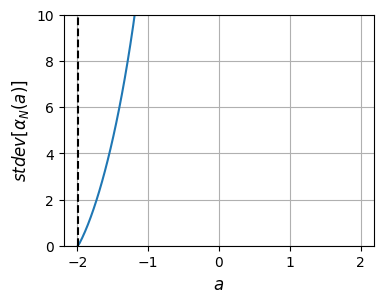

alpha_heu: 0.2878608942251526
0.2878608942251526


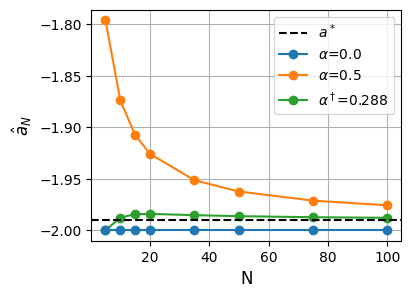

a2_heu: -1.8979565232784168


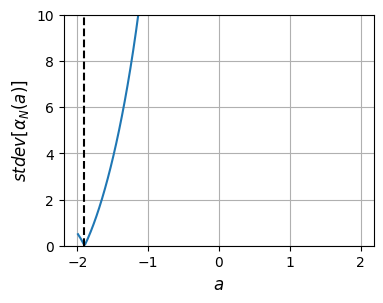

alpha_heu: 0.27018798596216886
0.27018798596216886


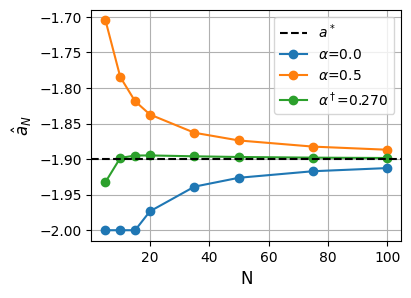

a2_heu: -1.500504231152973


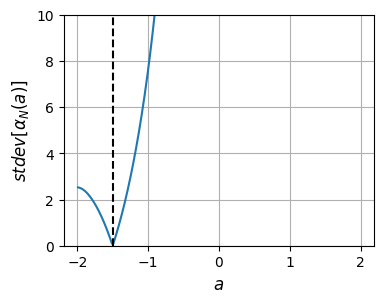

alpha_heu: 0.22531471414862747
0.22531471414862747


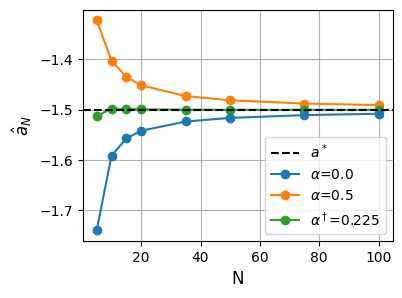

a2_heu: -1.0008352426359437


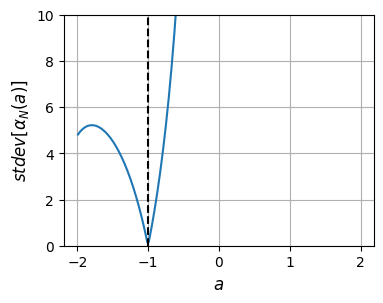

alpha_heu: 0.2108213220454177
0.2108213220454177


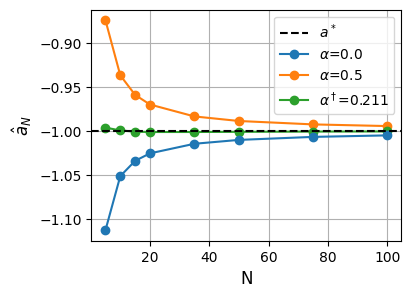

a2_heu: -0.5004578579197994


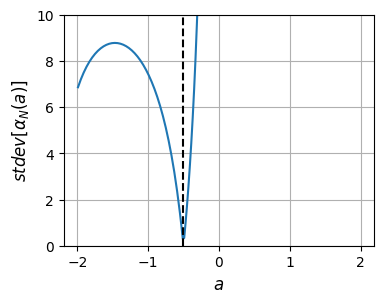

alpha_heu: 0.20850806087664903
0.20850806087664903


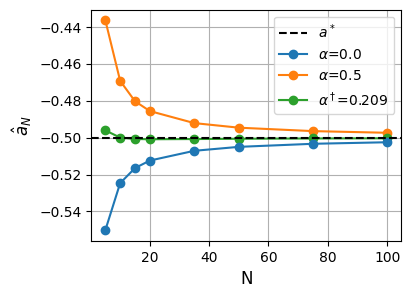

a2_heu: -0.10009217819965896


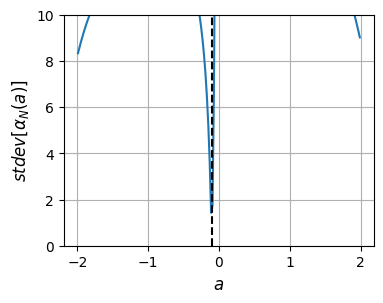

alpha_heu: 0.20837913134116998
0.20837913134116998


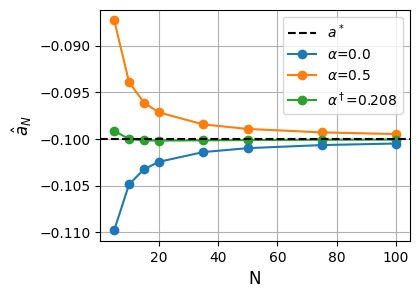

In [25]:
for a1 in a1_set:
    res_set[str(a1)] = get_alpha_dagger(a1, N_set)

# $a^*$=1

In [11]:
a1=1
N_set = [5,10,15,20,35,50,75,100]

In [12]:
m1_a1s = dict()
for N in N_set:
    m1_a1s[str(N)] = np.array([get_m1_k(a1, i+1, N) for i in range(N)])

In [13]:
a2_set = np.concatenate([np.linspace(-1.99, 1.99, 200)])
temp_alpha_set = np.empty((len(a2_set), len(N_set)))
S_grad_set = np.empty((len(a2_set), len(N_set)))
J_SDa_set = np.empty((len(a2_set), len(N_set)))
for i, a2 in enumerate(a2_set):
    for j, N in enumerate(N_set):
        S_grad = expected_self_wasserstein_loss_affine_grad(a2, N)
        J_SDa_grad = expected_W_emp_conti_affine_grad(a1, a2, N, m1s = m1_a1s[str(N)])
        temp_alpha = J_SDa_grad / S_grad
        temp_alpha_set[i,j] = temp_alpha
        S_grad_set[i,j] = S_grad
        J_SDa_set[i,j] = J_SDa_grad

In [15]:
a2_heu, fval = minimise_alpha_var(a1, N_set, m1_a1s=m1_a1s)
a2_heu

1.0008352417509996

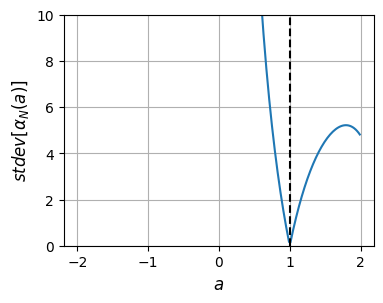

In [25]:
plt.figure(figsize=(4,3))
plt.plot(a2_set, np.std(temp_alpha_set, axis=-1))
plt.ylim(0,10)
plt.grid()
plt.xlabel(r'$a$', fontsize=12)
plt.ylabel(r'$stdev[\alpha_{N}(a)]$', fontsize=12)
plt.axvline([a1], color="k", linestyle="dashed")
# plt.legend()
# plt.savefig(f'./fig_expected_loss_SD_misspecified.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [16]:
temp_alpha_heu_set = np.empty(len(N_set))
for j, N in enumerate(N_set):
    S_grad_heu = expected_self_wasserstein_loss_affine_grad(a2_heu, N)
    J_SDa_grad_heu = expected_W_emp_conti_affine_grad(a1, a2_heu, N, m1s = m1_a1s[str(N)])
    temp_alpha_heu_set[j] = J_SDa_grad_heu / S_grad_heu
alpha_heu = np.mean(temp_alpha_heu_set)
alpha_heu

0.21082133803584568

In [19]:
sorted_a2 = a2_set[np.argsort(np.std(temp_alpha_set, axis=-1))]
sorted_a2[0], sorted_a2[1]

(1.01, 0.99)

In [22]:
idx=0
a2 = sorted_a2[idx]
a_set = np.empty(len(N_set))
a_bias_corrected_a0_5 = np.empty(len(N_set))
a_bias_corrected_a = np.empty(len(N_set))
temp_alphas = np.empty(len(N_set))
alpha = alpha_heu
print(alpha)
for i, N in enumerate(N_set):
    print(N)
    a_set[i], _ = minimise_expected_W_emp_conti(a1, N, m1_a1=m1_a1s[str(N)], alpha=0)
    a_bias_corrected_a0_5[i], _ = minimise_expected_W_emp_conti(a1, N, m1_a1=m1_a1s[str(N)], alpha=0.5)
    
    S_grad = expected_self_wasserstein_loss_affine_grad(a2, N)
    J_SDa_grad = expected_W_emp_conti_affine_grad(a1, a2, N, m1s = m1_a1s[str(N)])
    temp_alpha = J_SDa_grad / S_grad
    print(temp_alpha)
    a_bias_corrected_a[i], _ =minimise_expected_W_emp_conti(a1, N, m1_a1=m1_a1s[str(N)], alpha=alpha)

0.21082133803584568
5
0.18332120045567038
10
0.16646252327919075
15
0.15182881896387038
20
0.1344765986275846
35
0.07371839559424843
50
0.007521637694258106
75
-0.10689167083236803
100
-0.2233181471568773


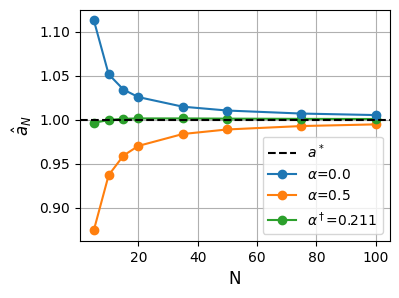

In [26]:
plt.figure(figsize=(4,3))
plt.axhline([a1], color='k', ls='--', label=r'$a^*$', zorder=20)
plt.plot(N_set, a_set, label=r'$\alpha$=0.0', marker='o', zorder=10)
plt.plot(N_set, a_bias_corrected_a0_5, label=r'$\alpha$=0.5', marker='o', zorder=3)
plt.plot(N_set, a_bias_corrected_a, label=rf'$\alpha^\dagger$={alpha:.3f}', marker='o', zorder=5)
plt.grid()
plt.xlabel(f'N', fontsize=12)
plt.ylabel(r'$\hat{a}_N$', fontsize=12)
# plt.ylim(-1, -0.95)
plt.legend()
# plt.savefig(f'./fig_bias_reduction_SD_well.pdf', format='pdf', bbox_inches="tight", dpi=300)